In [60]:
import sklearn.datasets as sk
import numpy as np
import pandas as pd


data = sk.fetch_lfw_people()
df = pd.DataFrame(data.data)
# df["target"]=data.target
count_faces = pd.DataFrame(data=np.vstack(np.unique(data.target,return_counts=True)).T,columns=["target","number"])
count_faces.sort_values("number")
df=df[np.isin(data.target,count_faces[count_faces.number > 100].target)]
print(f"number of images: {df.shape[0]}")
print(f"number of pixels: {df.shape[1]}")


number of images: 1140
number of pixels: 2914


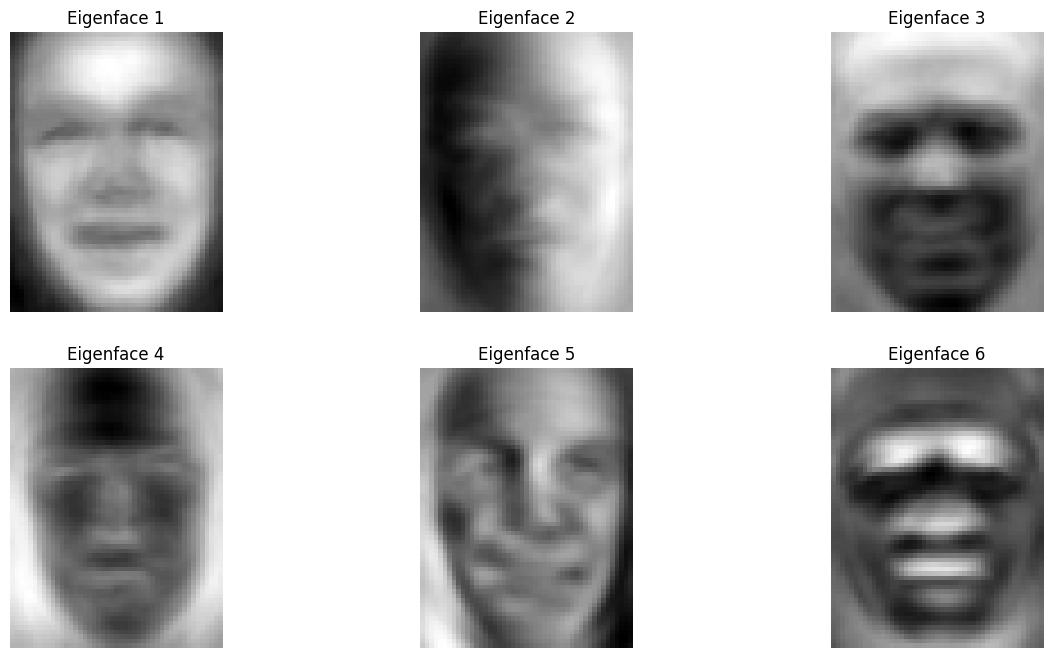

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

scaler = StandardScaler()
df_scale = pd.DataFrame(scaler.fit_transform(df))
pca = PCA(n_components=6)
X_pca = pca.fit_transform(df_scale)

img_shape = data.images[0].shape

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, i in zip(axes, range(6)):
    pca_image = pca.components_[i].reshape(img_shape)
    im = ax.imshow(pca_image, cmap='gray')
    ax.set_title(f"Eigenface {i+1}")
    ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.show()

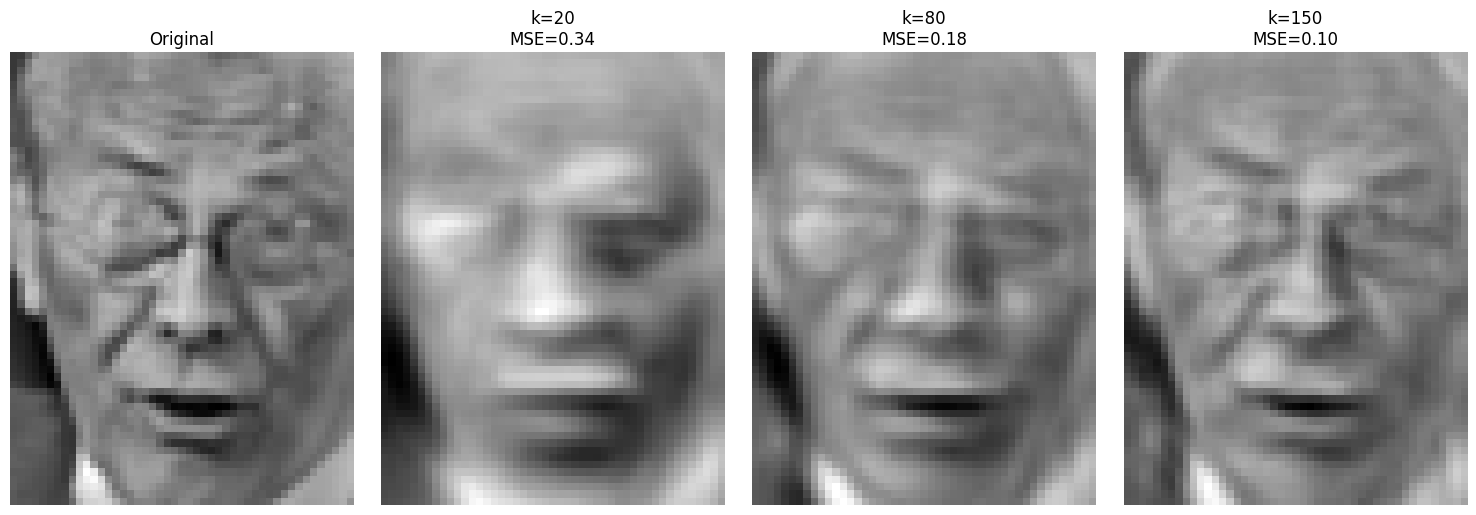

(2914,)

In [ ]:
from sklearn.metrics import mean_squared_error

k_values = [20, 80, 150]
reconstructed_imgs = []

img_index = 0
original_img = df_scale.values[img_index].reshape(data.images[0].shape)

for k in k_values:
    pca = PCA(n_components=k)
    X_pca = pca.fit_transform(df_scale)    
    reconstructed_imgs.append(pca.inverse_transform(X_pca[img_index]))
    
mses = [mean_squared_error(df_scale.iloc[img_index],reconstructed_img) for reconstructed_img in reconstructed_imgs]

fig, axes = plt.subplots(1, len(k_values)+1, figsize=(15,5))

axes[0].imshow(original_img, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

for ax, img, k, mse in zip(axes[1:], reconstructed_imgs, k_values, mses):
    ax.imshow(img.reshape(data.images[0].shape), cmap='gray')
    ax.set_title(f"k={k}\nMSE={mse:.2f}")
    ax.axis('off')

plt.tight_layout()
plt.show()


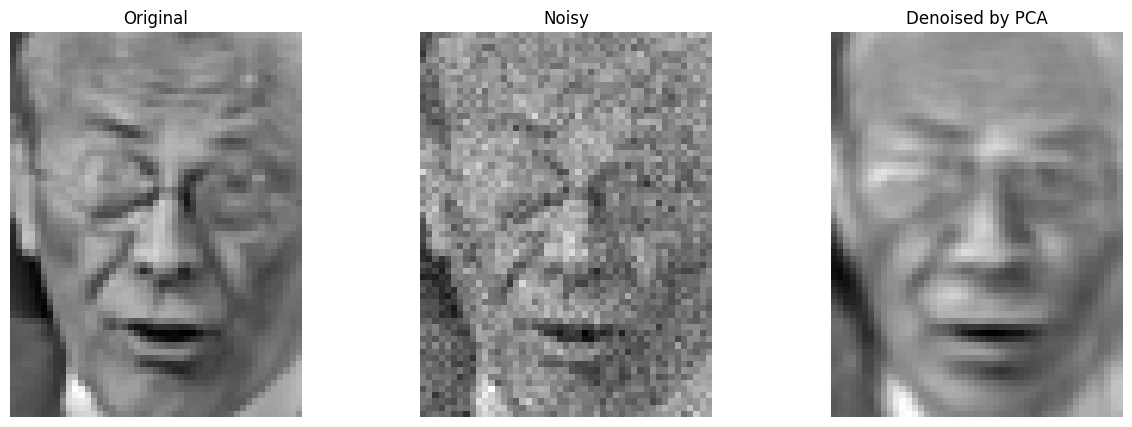

In [93]:

noise = np.random.normal(0, 0.5, df_scale.values[img_index].size)
noisy = df_scale.values[img_index] + noise
noisy_img = noisy.reshape(img_shape)

pca = PCA(n_components=100)
pca.fit(df_scale)

noisy_pca = pca.transform(noisy.reshape(1, -1))

reconstructed = pca.inverse_transform(noisy_pca).flatten()
reconstructed_img = reconstructed.reshape(img_shape)

fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].imshow(original_img, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(noisy_img, cmap='gray')
axes[1].set_title("Noisy")
axes[1].axis('off')

axes[2].imshow(reconstructed_img, cmap='gray')
axes[2].set_title("Denoised by PCA")
axes[2].axis('off')

plt.show()


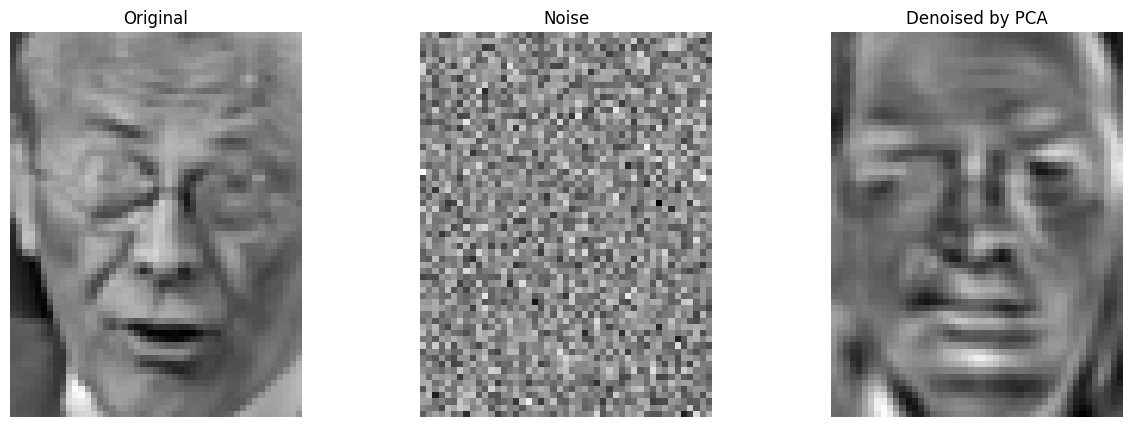

In [94]:
noise_img = noise.reshape(img_shape)
noise_pca = pca.transform(noise.reshape(1, -1))

reconstructed = pca.inverse_transform(noise_pca).flatten()
reconstructed_img = reconstructed.reshape(img_shape)

fig, axes = plt.subplots(1, 3, figsize=(15,5))

axes[0].imshow(original_img, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(noise_img, cmap='gray')
axes[1].set_title("Noise")
axes[1].axis('off')

axes[2].imshow(reconstructed_img, cmap='gray')
axes[2].set_title("Denoised by PCA")
axes[2].axis('off')

plt.show()